# [LAB 11] 2. 시계열 데이터의 평활(연습문제)
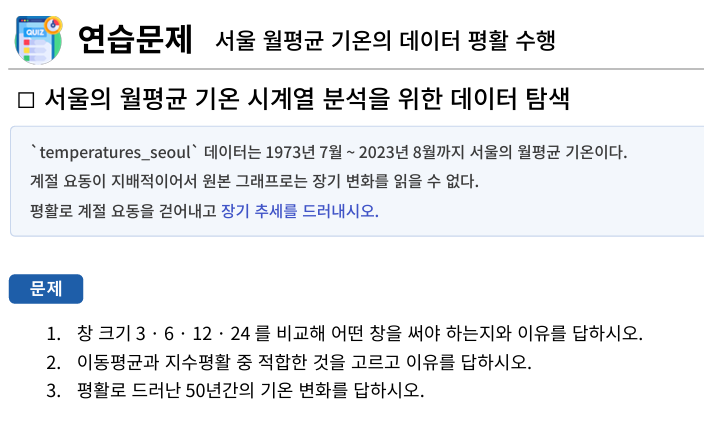

In [30]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *

In [31]:
origin = load_data('temperatures_seoul')
origin.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)


,날짜,평균기온(℃)
0,1973-07-01,26.816
1,1973-08-01,25.884
2,1973-09-01,20.323
3,1973-10-01,13.039
4,1973-11-01,4.723


In [32]:
df = my_ts.set_index(origin, '날짜', freq='MS')
print('인덱스 간격(freq):', df.index.freqstr)
df.head()

인덱스 간격(freq): MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


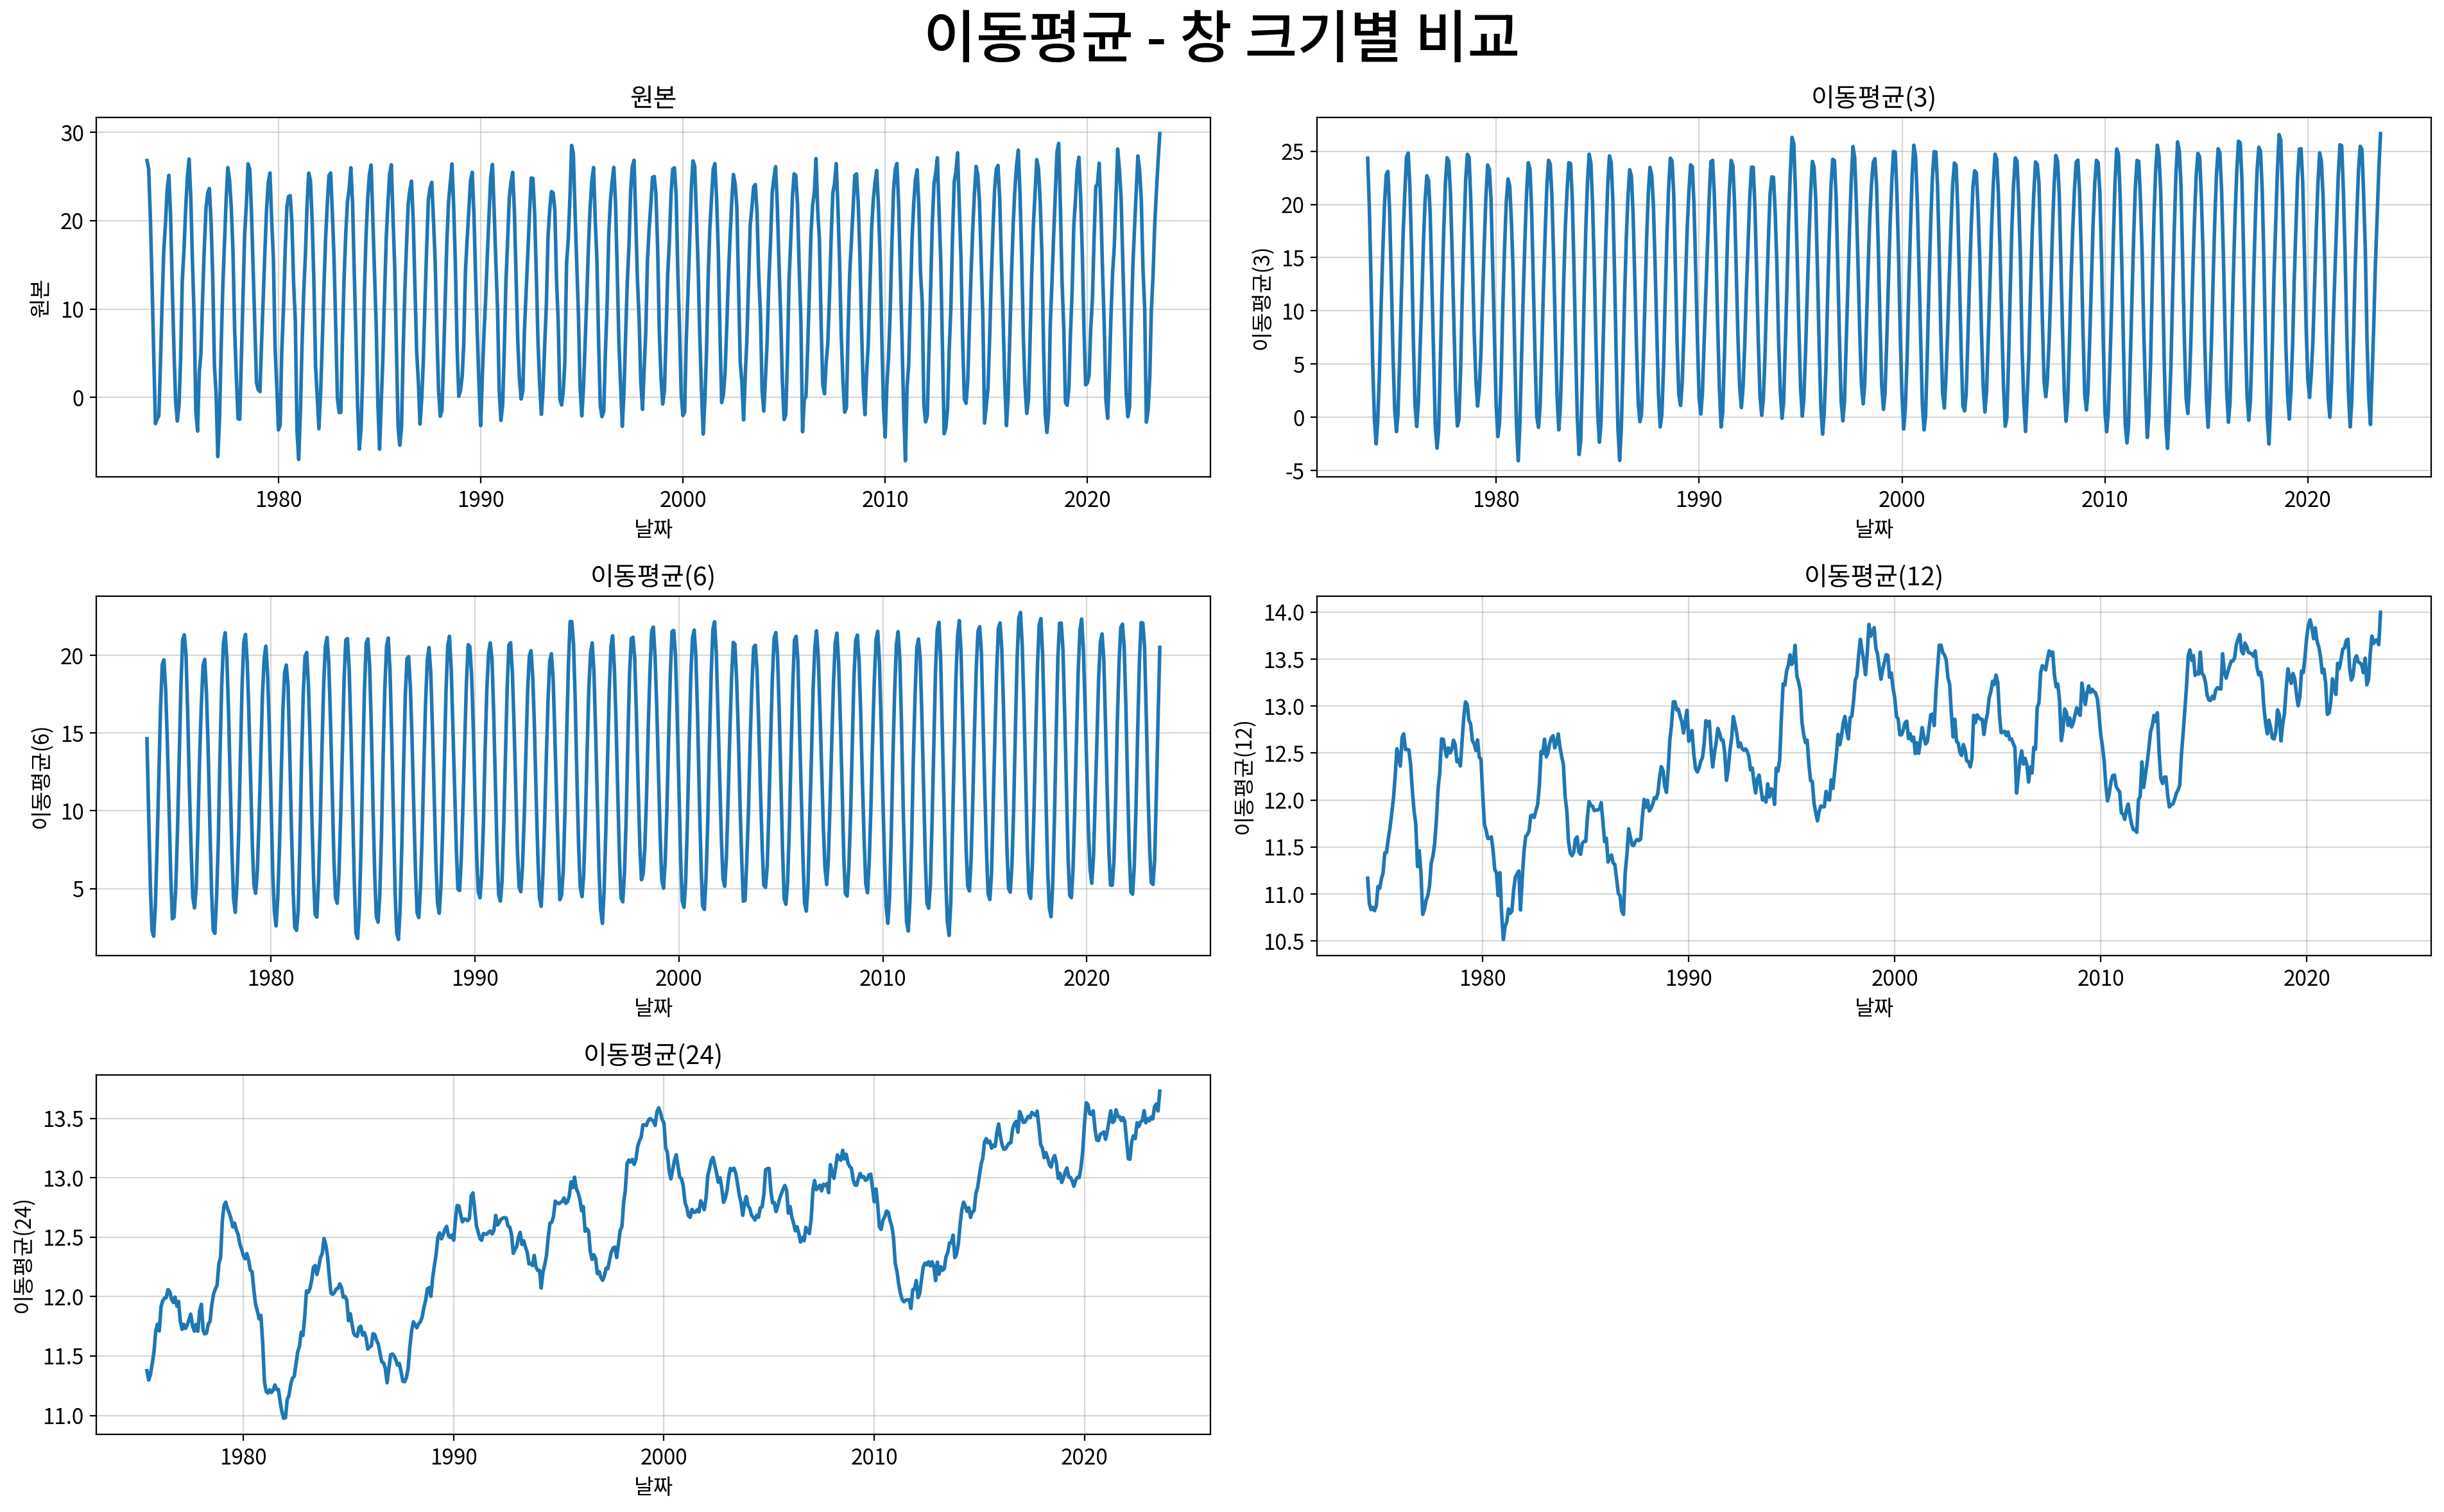

,원본,이동평균(3),이동평균(6),이동평균(12),이동평균(24)
날짜,,,,,
1973-07-01,26.816,NaN,NaN,NaN,NaN
1973-08-01,25.884,NaN,NaN,NaN,NaN
1973-09-01,20.323,24.341,NaN,NaN,NaN
1973-10-01,13.039,19.749,NaN,NaN,NaN
1973-11-01,4.723,12.695,NaN,NaN,NaN
...,...,...,...,...,...
2023-04-01,13.800,8.627,5.262,13.666,13.495
2023-05-01,19.523,14.368,6.844,13.699,13.597
2023-06-01,23.383,18.902,11.211,13.706,13.620


In [33]:
# 문제 1
ma_result = my_ts.compare_smoothing(df, (3,6,12,24), '평균기온(℃)', method='ma', title='이동평균 - 창 크기별 비교')
ma_result

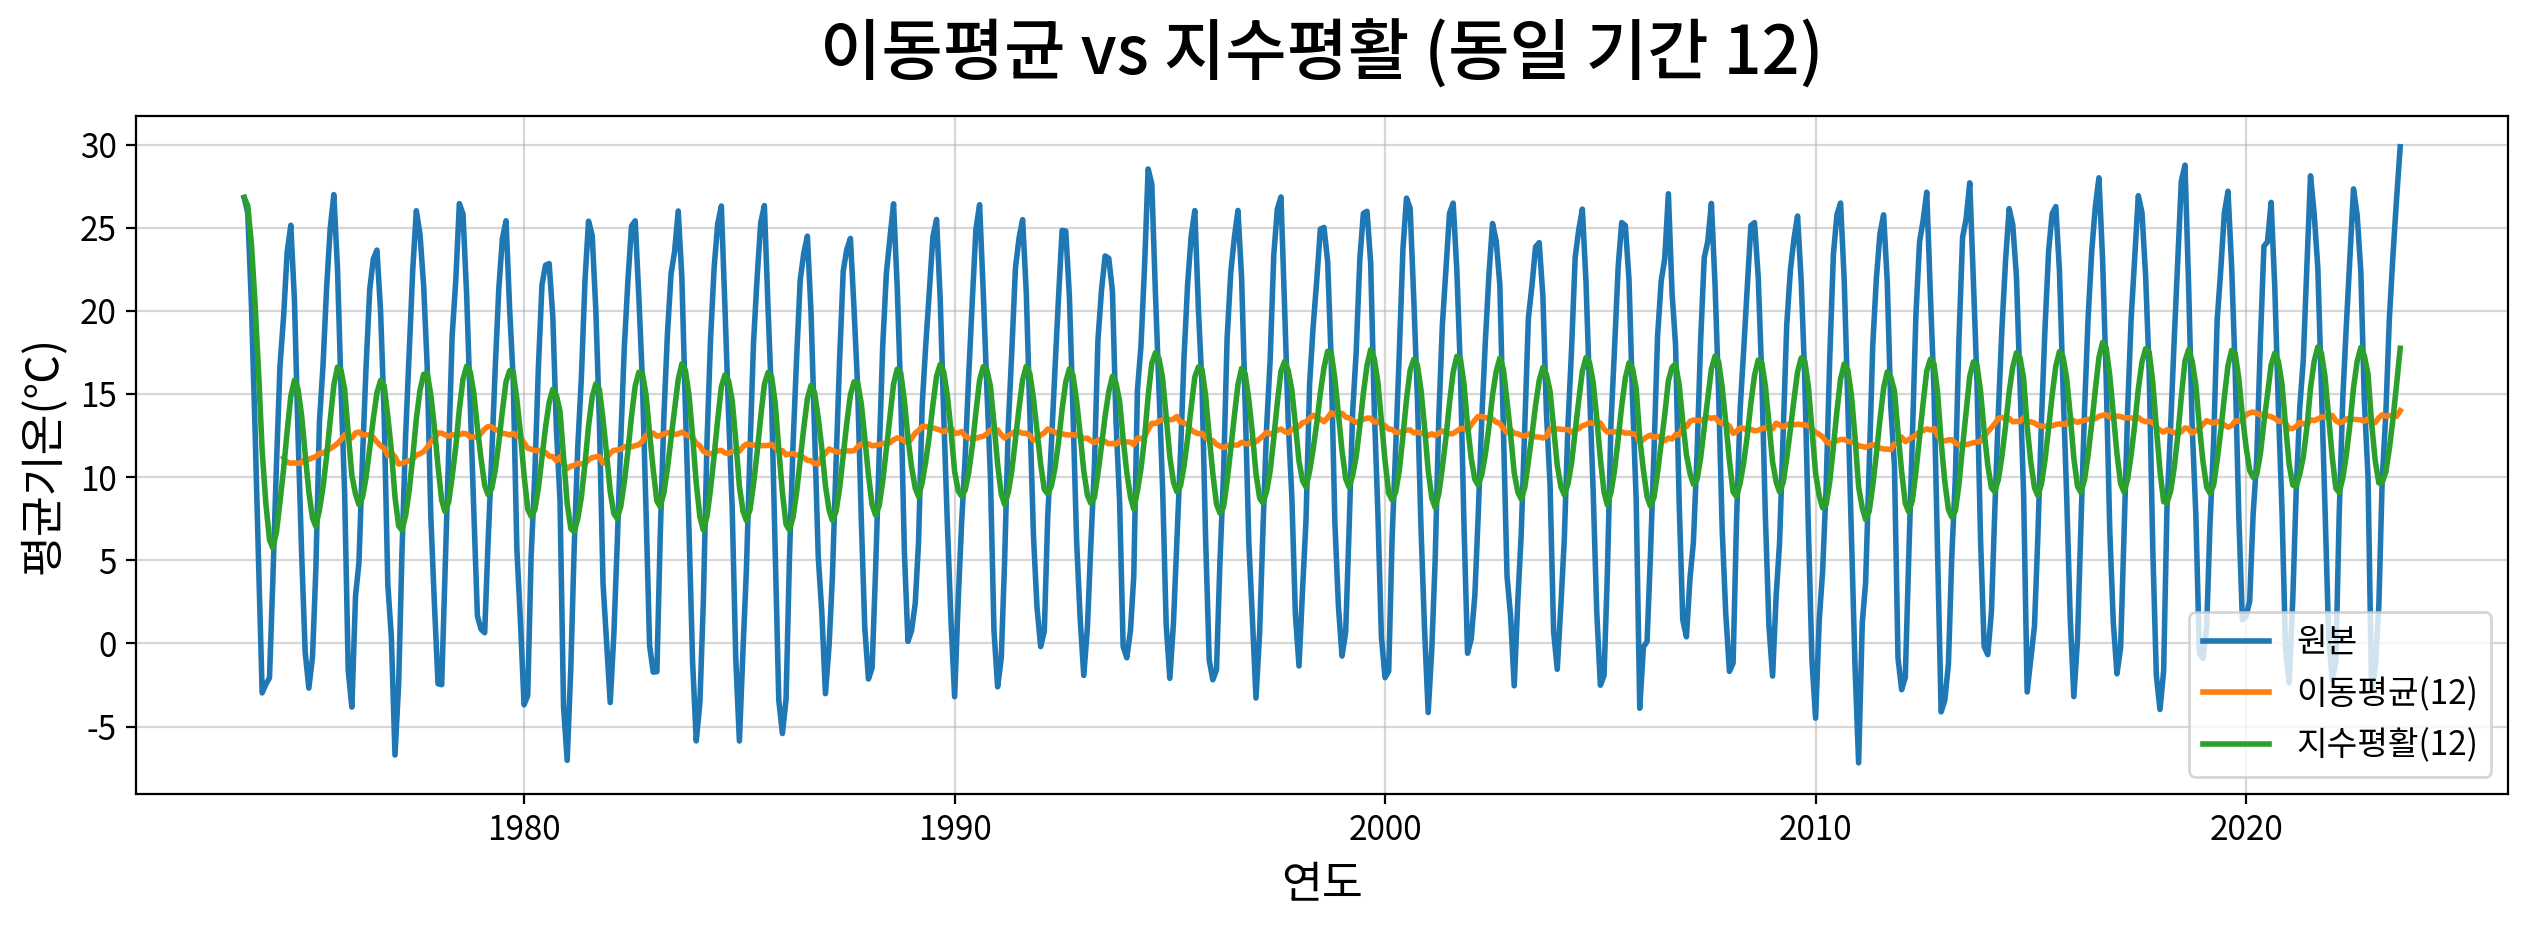

,원본,이동평균(12),지수평활(12)
날짜,,,
1973-07-01,26.816,NaN,26.816
1973-08-01,25.884,NaN,26.311
1973-09-01,20.323,NaN,23.974
1973-10-01,13.039,NaN,20.522
1973-11-01,4.723,NaN,16.230
...,...,...,...
2023-04-01,13.800,13.666,10.303
2023-05-01,19.523,13.699,11.722
2023-06-01,23.383,13.706,13.516


In [34]:
both_result = my_ts.compare_smoothing(df, [12], '평균기온(℃)', method='both', overlay=True,
                                      title='이동평균 vs 지수평활 (동일 기간 12)',
                                      xlabel='연도', ylabel='평균기온(℃)',
                                      width=1280, height=480)

both_result

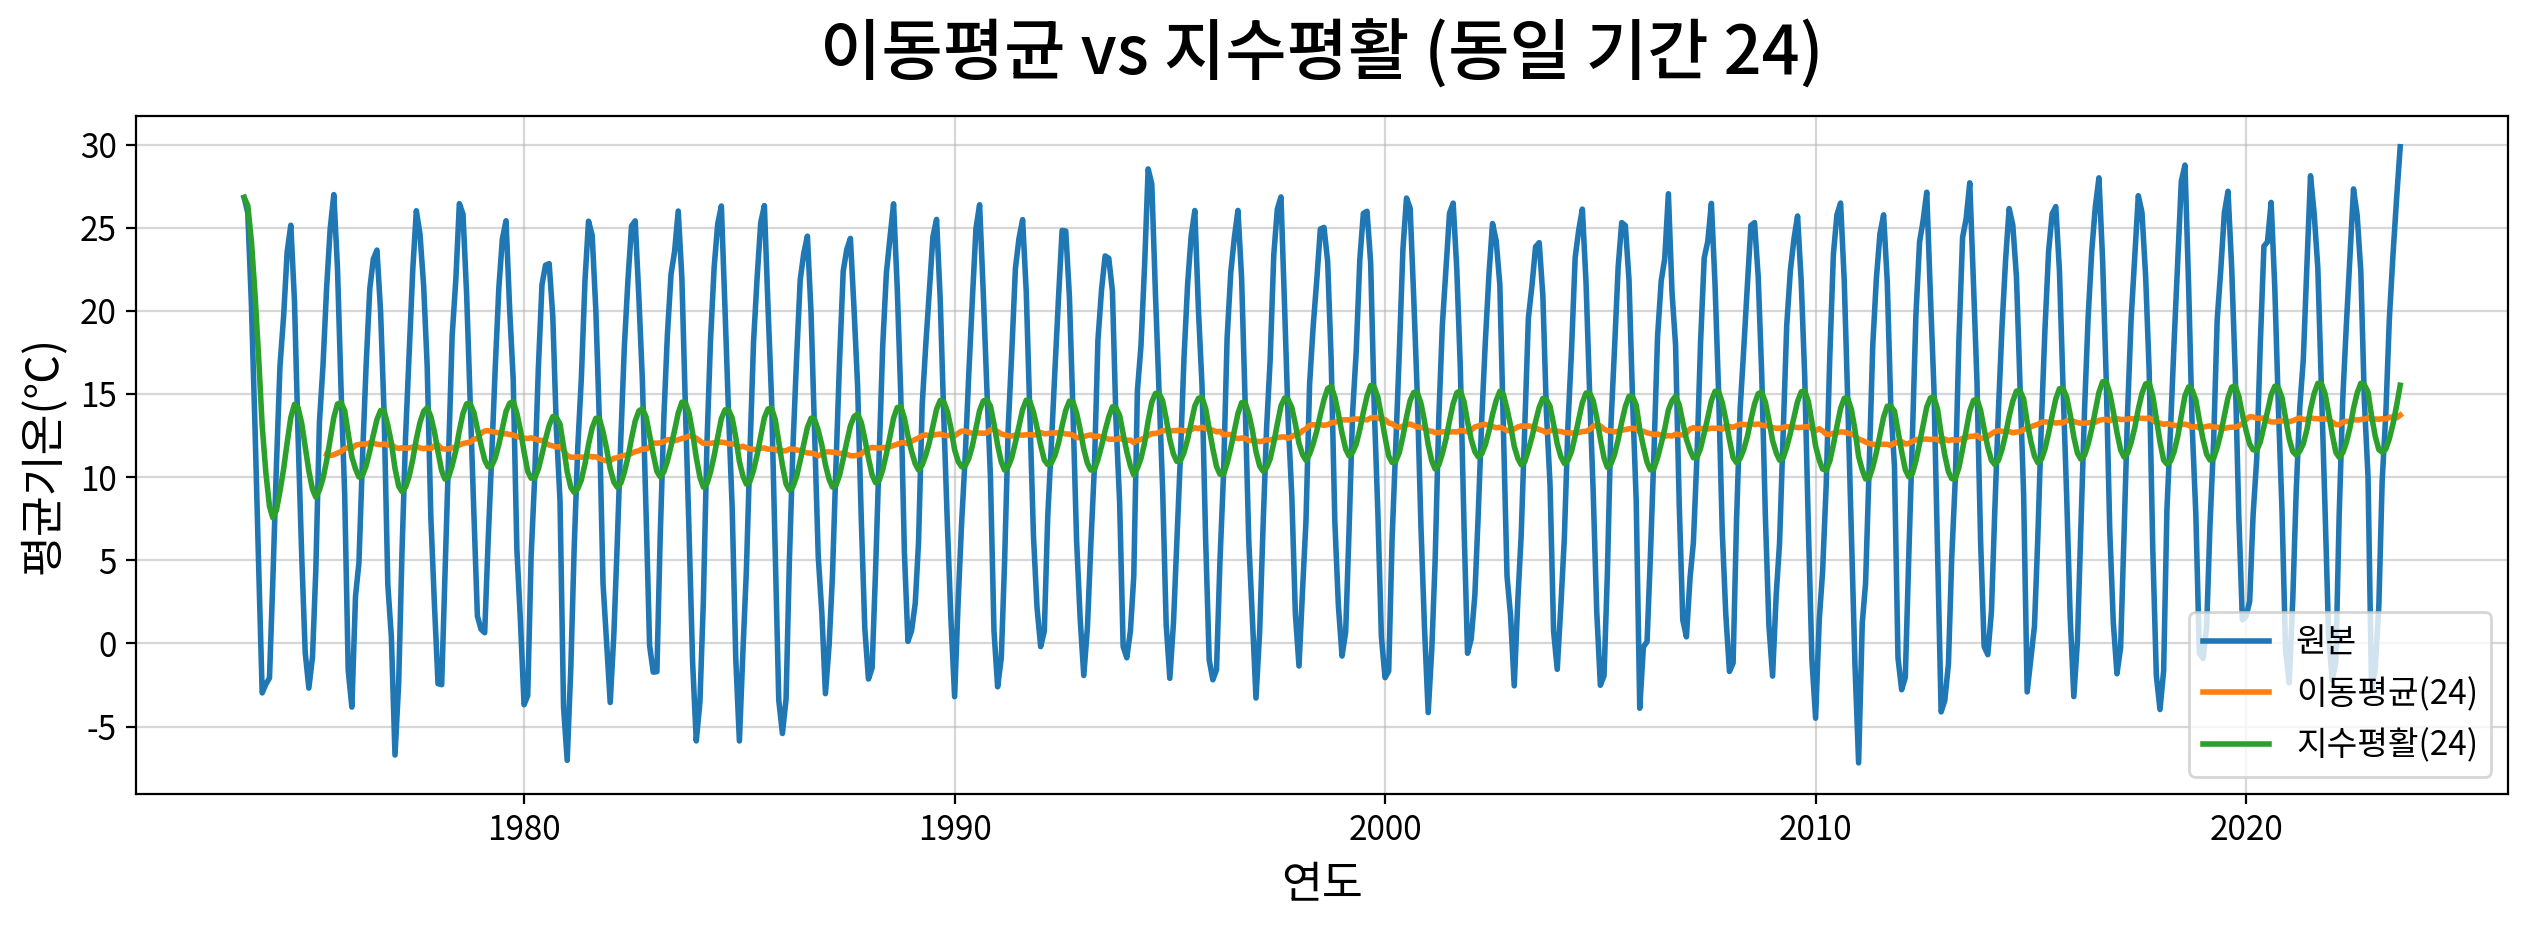

,원본,이동평균(24),지수평활(24)
날짜,,,
1973-07-01,26.816,NaN,26.816
1973-08-01,25.884,NaN,26.331
1973-09-01,20.323,NaN,24.159
1973-10-01,13.039,NaN,21.022
1973-11-01,4.723,NaN,17.198
1973-12-01,-2.977,NaN,13.097
1974-01-01,-2.458,NaN,10.283
1974-02-01,-2.079,NaN,8.251
1974-03-01,3.687,NaN,7.560


,원본,이동평균(24),지수평활(24)
날짜,,,
2021-08-01,25.858,13.516,15.028
2021-09-01,22.597,13.514,15.633
2021-10-01,15.574,13.481,15.629
2021-11-01,8.180,13.506,15.033
2021-12-01,0.584,13.471,13.877
2022-01-01,-2.197,13.312,12.591
2022-02-01,-1.125,13.159,11.494
2022-03-01,7.655,13.156,11.186
2022-04-01,14.753,13.307,11.472


In [35]:

both_result = my_ts.compare_smoothing(df, [24], '평균기온(℃)', method='both', overlay=True,
                                      title='이동평균 vs 지수평활 (동일 기간 24)',
                                      xlabel='연도', ylabel='평균기온(℃)',
                                      width=1280, height=480)

display(both_result.head(40))
display(both_result.tail(25))



In [36]:
both_result["연도"] = both_result.index.year

early = both_result[(both_result["연도"] >= 1974) & (both_result["연도"] <= 1983)]["이동평균(24)"].mean()
late = both_result[(both_result["연도"] >= 2013) & (both_result["연도"] <= 2022)]["이동평균(24)"].mean()

early, late, late - early

(np.float64(11.870614699240315),
 np.float64(13.16204371001583),
 np.float64(1.2914290107755146))

#### 문제 1
- 24를 사용. 해당 데이터는 굉장히 장기간의 데이터이므로 장기 추세를 보기 위해서는 24개월의 이동평균이 가장 적합하다고 판단하였다. 12개월 이동평균도 계절성을 제거할 수는 있으나 24개월은 두 해를 평균내기 때문에 장기적인 추세를 드러내기에 12개월보다 적합하다고 판단했다.

#### 문제 2
- 이동평균을 사용. 지수평활은 최근 값에 더 큰 가중치를 주기 때문에 계절 요동을 걷어내고 장기 추세를 판단하는데에는 이동평균을 사용하는 것이 적합나다.

#### 문제 3. 50년간 기온변화
- 시각적으로 확인했을 때 초기구간보다 후반구간의 평활그래프가 15℃에 가까워지는걸 확인할 수 있다. 
- 실제 값으로 확인해보면 24개월 이동평균 초기값은 약 11.38℃였고, 마지막값은 약 13.73℃로 2.35℃ 상승하였다. 또 초기 10년과 후기 10년의 이동평균 값을 비교하면 초기 10년의 이동평균 값은 11.87℃, 후반 10년 13.16℃로 둘의 차이는 1.29℃이다.
- 따라서 서울의 월평균 기온은 50년동안 장기적으로 상승했다고 볼 수 있다.